In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error

color_pal = sns.color_palette()  # define color palette
plt.style.use('fivethirtyeight')

In [2]:
#!pip install xgboost

In [3]:
filepath = "C:\\Users\\dkhan\\Desktop\\Python\\Machine Learning\\Time_Series\\pjme_hourly.csv"
df = pd.read_csv(filepath)
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [5]:
df.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [6]:
df.dropna()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
...,...,...
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0


In [7]:
df = df.set_index('Datetime')

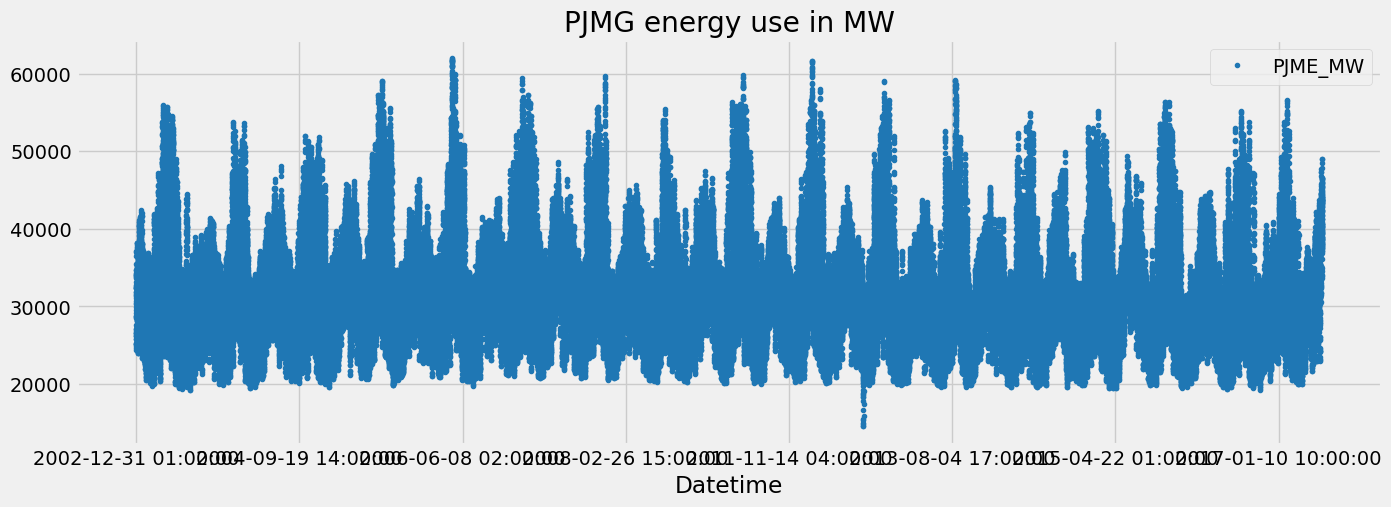

In [8]:
df.plot(style='.', figsize=(15,5), color=color_pal[0], title='PJMG energy use in MW')
plt.show()

In [9]:
df.index

Index(['2002-12-31 01:00:00', '2002-12-31 02:00:00', '2002-12-31 03:00:00',
       '2002-12-31 04:00:00', '2002-12-31 05:00:00', '2002-12-31 06:00:00',
       '2002-12-31 07:00:00', '2002-12-31 08:00:00', '2002-12-31 09:00:00',
       '2002-12-31 10:00:00',
       ...
       '2018-01-01 15:00:00', '2018-01-01 16:00:00', '2018-01-01 17:00:00',
       '2018-01-01 18:00:00', '2018-01-01 19:00:00', '2018-01-01 20:00:00',
       '2018-01-01 21:00:00', '2018-01-01 22:00:00', '2018-01-01 23:00:00',
       '2018-01-02 00:00:00'],
      dtype='object', name='Datetime', length=145366)

In [10]:
df.index = pd.to_datetime(df.index)
#df.index

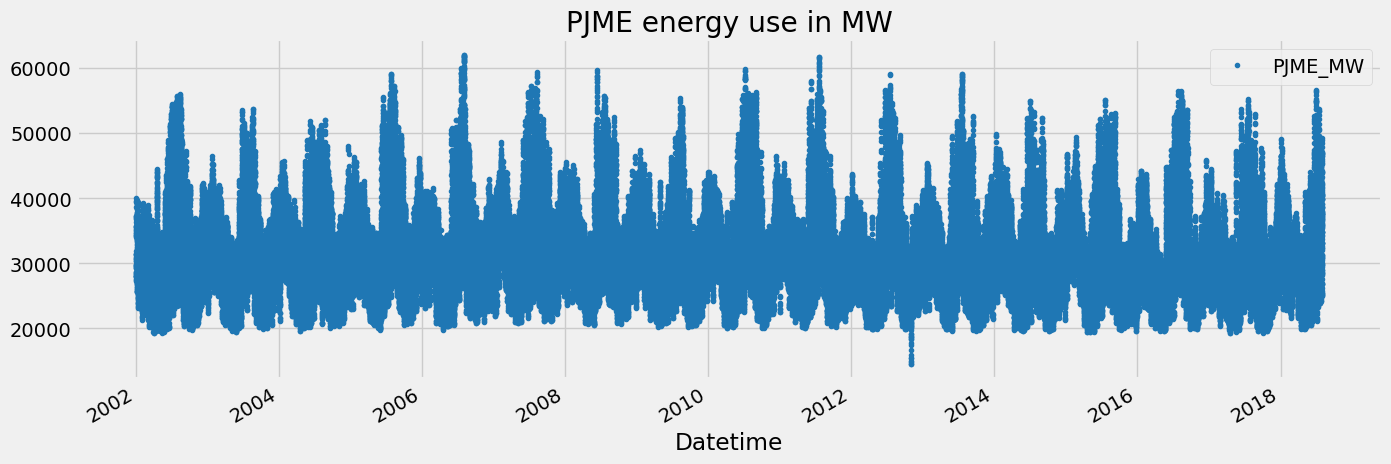

In [11]:
df.plot(style='.', 
        figsize=(15,5), 
        color=color_pal[0], 
        title='PJME energy use in MW')
plt.show()

### Train Test Split

In [12]:
train = df.loc[df.index<'01-01-2015']
test = df.loc[df.index>='01-01-2015']

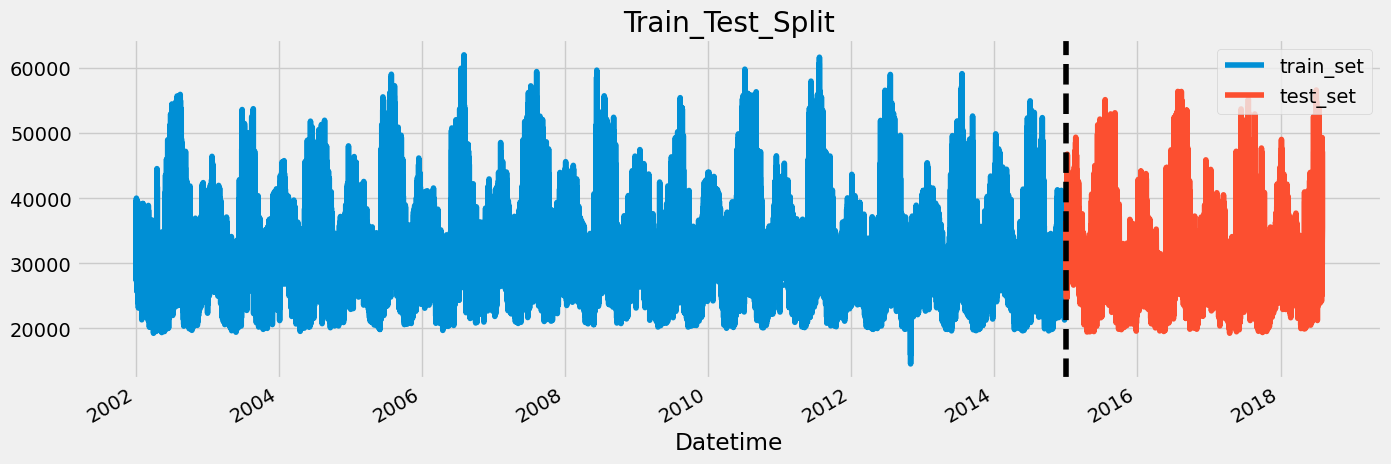

In [13]:
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label= 'training set', title='Train_Test_Split')
test.plot(ax=ax, label='test set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['training_set', 'test_set'])
plt.show()

In [14]:
df.loc[(df.index>'01-01-2010') & (df.index<'01-08-2010')]

,PJME_MW
Datetime,
2010-01-07 01:00:00,32194.0
2010-01-07 02:00:00,31254.0
2010-01-07 03:00:00,30894.0
2010-01-07 04:00:00,30937.0
2010-01-07 05:00:00,31660.0
...,...
2010-01-01 20:00:00,35385.0
2010-01-01 21:00:00,35105.0
2010-01-01 22:00:00,34309.0


C:\Users\dkhan\AppData\Local\Temp\ipykernel_41700\4048079287.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  subset = subset.asfreq('H')


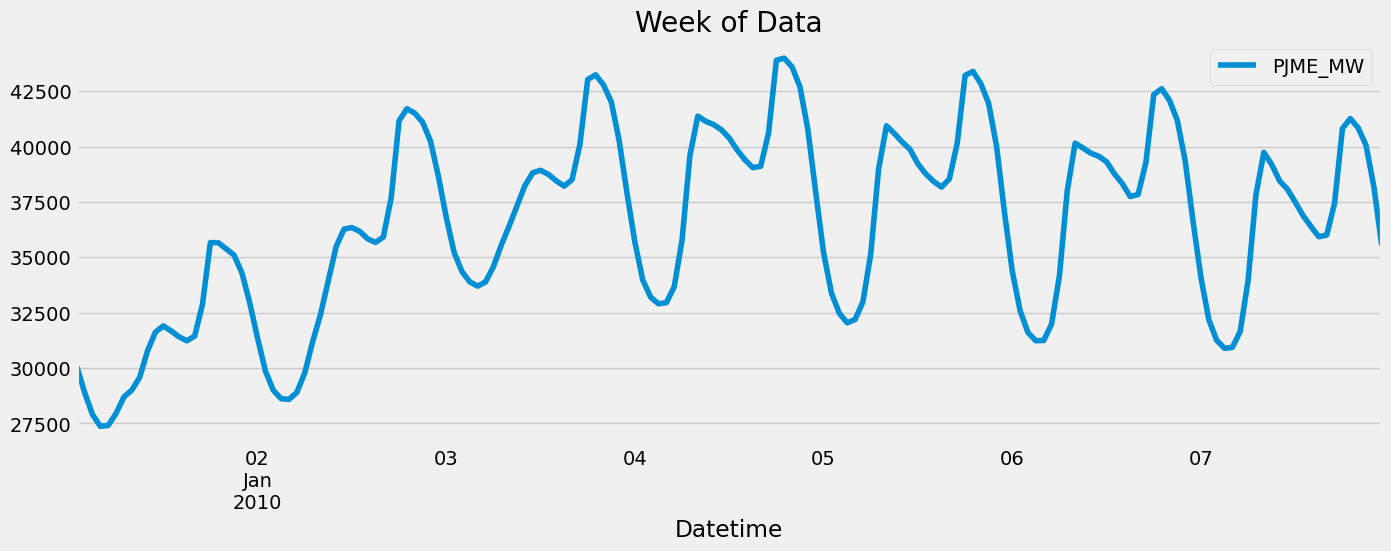

In [15]:
df = df.sort_index()

# Select the week once
subset = df.loc['2018-04-01':'2018-04-08'].copy()

# Break line at missing timestamps (important)
subset = subset.asfreq('H')

df.loc[(df.index > '2010-01-01') & (df.index < '2010-01-08')] \
  .plot(figsize=(15, 5), title='Week of Data')

plt.show()

#### Freature Creation

In [16]:
df.index.hour

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
       15, 16, 17, 18, 19, 20, 21, 22, 23,  0],
      dtype='int32', name='Datetime', length=145366)

In [17]:
df['hour']=df.index.hour 
df.head()

,PJME_MW,hour
Datetime,,
2002-01-01 01:00:00,30393.0,1
2002-01-01 02:00:00,29265.0,2
2002-01-01 03:00:00,28357.0,3
2002-01-01 04:00:00,27899.0,4
2002-01-01 05:00:00,28057.0,5


In [18]:
df['dayofweek']=df.index.day_of_week   # See pandas documentation
#(https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.dayofweek.html)
df.head() # Monday=0, Sunday=6

,PJME_MW,hour,dayofweek
Datetime,,,
2002-01-01 01:00:00,30393.0,1,1
2002-01-01 02:00:00,29265.0,2,1
2002-01-01 03:00:00,28357.0,3,1
2002-01-01 04:00:00,27899.0,4,1
2002-01-01 05:00:00,28057.0,5,1


In [19]:
df['quarter']=df.index.quarter  
df.head()

,PJME_MW,hour,dayofweek,quarter
Datetime,,,,
2002-01-01 01:00:00,30393.0,1,1,1
2002-01-01 02:00:00,29265.0,2,1,1
2002-01-01 03:00:00,28357.0,3,1,1
2002-01-01 04:00:00,27899.0,4,1,1
2002-01-01 05:00:00,28057.0,5,1,1


In [20]:
df['month']=df.index.month
df['year']=df.index.year
df['dayofyear']=df.index.dayofyear

In [21]:
def create_features(df):
    '''
    create time series features based on time series index.
    '''
    df =df.copy()
    df['hour']=df.index.hour 
    df['dayofweek']=df.index.day_of_week
    df['quarter']=df.index.quarter 
    df['month']=df.index.month
    df['year']=df.index.year
    df['dayofyear']=df.index.dayofyear
    return df

In [22]:
df = create_features(df)
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1
...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214


In [23]:
# Visualize Feature/Target Relationship

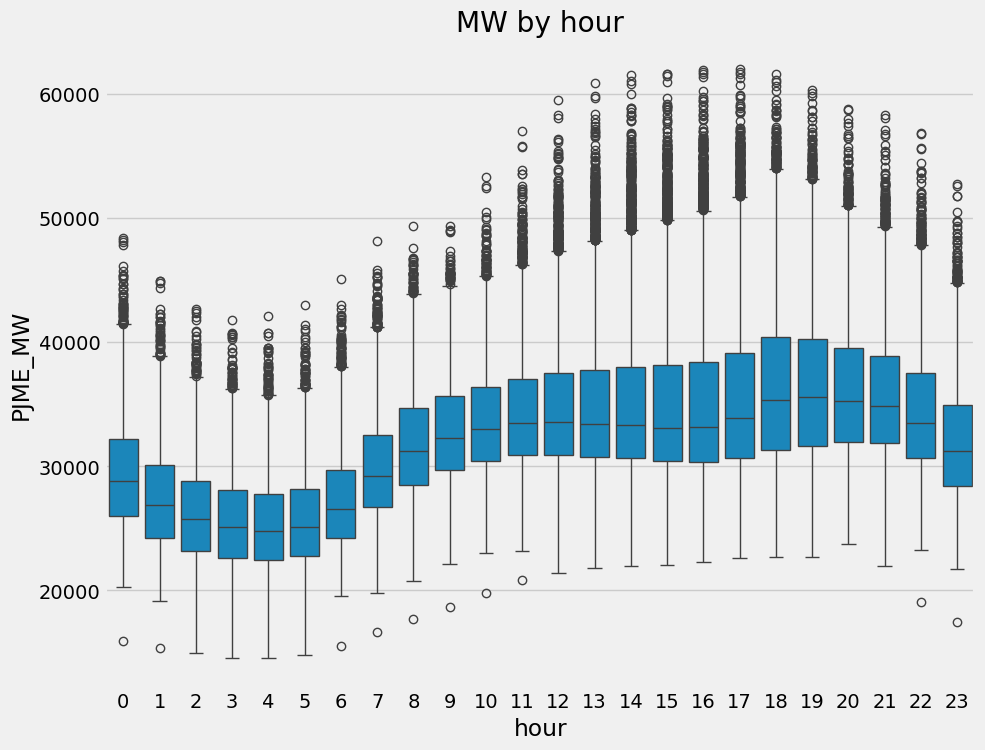

In [24]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by hour')
plt.show()

C:\Users\dkhan\AppData\Local\Temp\ipykernel_41700\2029217114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')


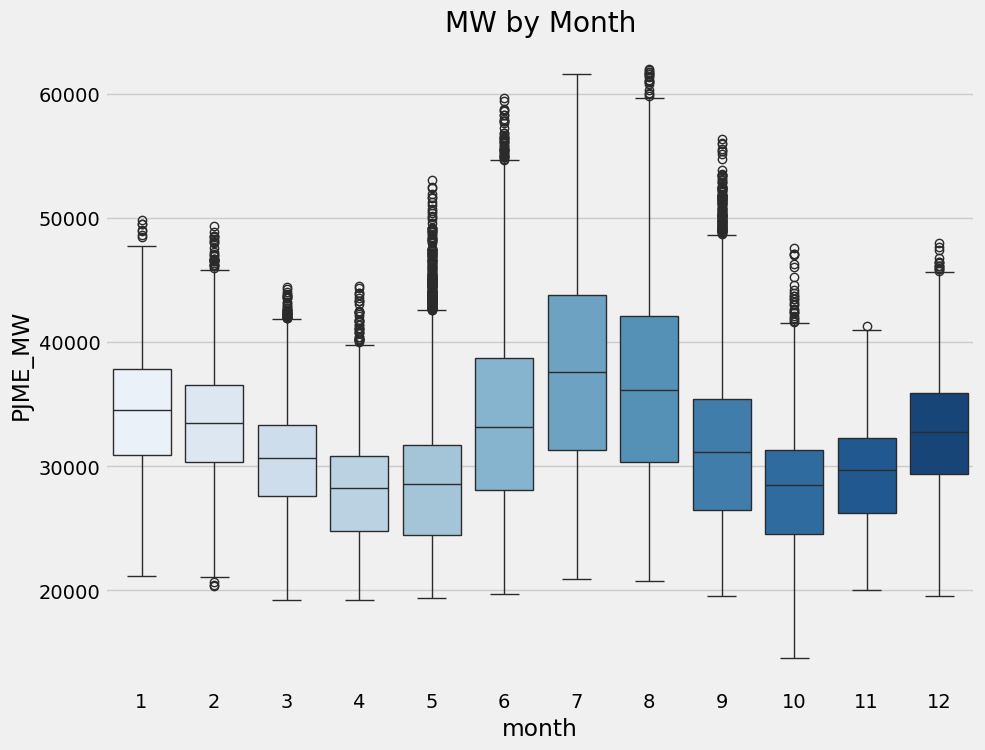

In [25]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

In [26]:
train = create_features(train)
test = create_features(test)

In [27]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='object')

In [28]:
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year','dayofyear']
TARGET = 'PJME_MW'

In [29]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

#### Create Our Model

In [30]:
reg =xgb.XGBRegressor(n_estimators=1000,
                     early_stopping_rounds=50,
                     learning_rate=0.01) # we use regression test

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)  # gives every 100

[0]	validation_0-rmse:6407.35736	validation_1-rmse:6479.81619
[100]	validation_0-rmse:3911.97994	validation_1-rmse:4312.03224
[200]	validation_0-rmse:3244.38509	validation_1-rmse:3864.56545
[300]	validation_0-rmse:2996.08999	validation_1-rmse:3748.76687
[400]	validation_0-rmse:2830.28024	validation_1-rmse:3744.93340
[417]	validation_0-rmse:2801.66222	validation_1-rmse:3749.26089


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Feature Importance

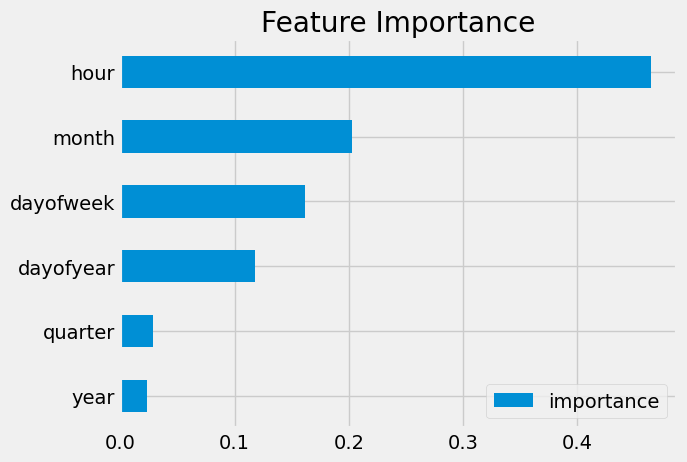

In [31]:
fi = pd.DataFrame(data=reg.feature_importances_, 
             index=reg.feature_names_in_,
            columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

#### Forecast On Test Set

In [32]:
reg.predict(X_test)

array([32393.352, 29040.168, 27877.018, ..., 36229.527, 35141.754,
       32339.713], dtype=float32)

In [33]:
test['Prediction'] = reg.predict(X_test)

In [34]:
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1
...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214


In [35]:
df = df.merge(test[['Prediction']], how='left', left_index=True, right_index=True)
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,Prediction
Datetime,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,NaN
...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,41545.953125
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,41135.625000
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,39968.492188


C:\Users\dkhan\AppData\Local\Temp\ipykernel_41700\4290249864.py:3: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Truth Data', 'Prediction')


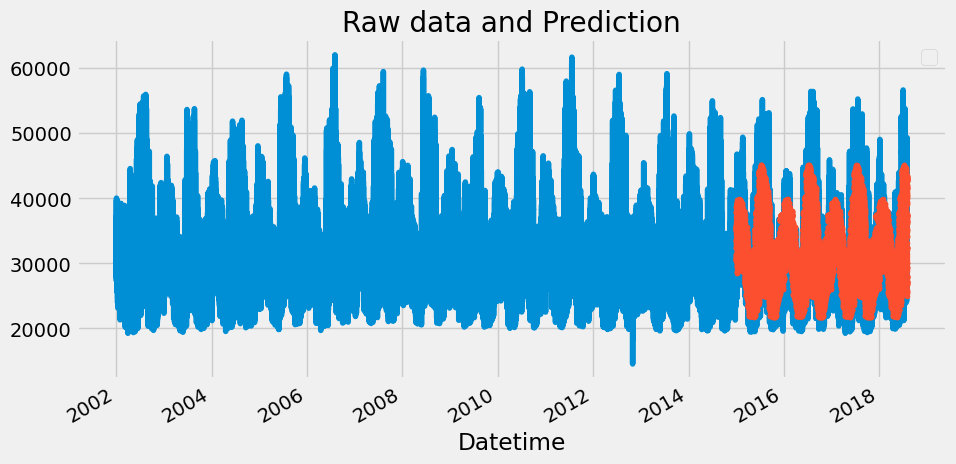

In [36]:
ax = df[['PJME_MW']].plot(figsize=(10,5))
df['Prediction'].plot(ax=ax, style='.')
plt.legend('Truth Data', 'Prediction')
ax.set_title('Raw data and Prediction')
plt.show()

C:\Users\dkhan\AppData\Local\Temp\ipykernel_41700\145102509.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  subset = subset.asfreq('H')


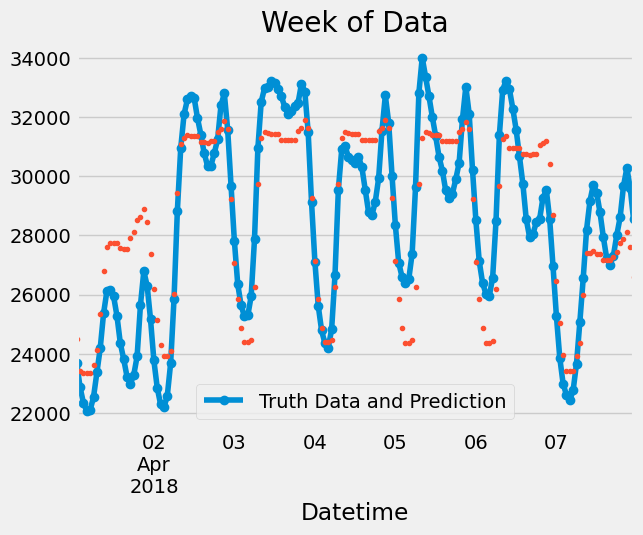

In [37]:
df = df.sort_index()

# Select the week once
subset = df.loc['2018-04-01':'2018-04-08'].copy()

# Break line at missing timestamps (important)
subset = subset.asfreq('H')

ax = df.loc[(df.index>'04-01-2018') & (df.index<'04-08-2018')]['PJME_MW']\
.plot(style='-o', title='Week of Data')
df.loc[(df.index>'04-01-2018') & (df.index<'04-08-2018')]['Prediction']\
.plot(style='.')
plt.legend(['Truth Data and Prediction'])
plt.show()

In [38]:
# Model is not perfect. we need to tune parameter.

In [39]:
score =np.sqrt(mean_squared_error(test['PJME_MW'], test['Prediction']))
print(f'RMSE score on test set: {score:.2f}')

RMSE score on test set: 3741.03


In [40]:
# this value is similar to above calculated trained model value

#### Calculate Error

In [41]:
np.abs(test[TARGET]-test['Prediction'])

Datetime
2015-01-01 00:00:00     408.648438
2015-12-31 01:00:00    4735.167969
2015-12-31 02:00:00    4721.017578
2015-12-31 03:00:00    5062.720703
2015-12-31 04:00:00    5246.720703
                          ...     
2018-01-01 20:00:00    5660.753906
2018-01-01 21:00:00    5255.515625
2018-01-01 22:00:00    6172.472656
2018-01-01 23:00:00    5022.246094
2018-01-02 00:00:00    6268.287109
Length: 31440, dtype: float64

In [42]:
# look at the best and worst predicted days

In [43]:
test['error']=np.abs(test[TARGET]-test['Prediction'])

In [44]:
test['date']=test.index.date

In [45]:
test.groupby('date')['error'].mean()

date
2015-01-01    2965.745036
2015-01-02    2350.001383
2015-01-03    1680.229492
2015-01-04    4003.939941
2015-01-05    2540.236572
                 ...     
2018-07-30    3206.202962
2018-07-31    1963.001058
2018-08-01    2724.754313
2018-08-02    3267.145915
2018-08-03    3187.994141
Name: error, Length: 1311, dtype: float64

In [46]:
test.groupby('date')['error'].mean().sort_values(ascending=False).head(5)

date
2016-08-13    13829.866211
2016-08-14    13577.304362
2016-09-10    11235.855143
2016-09-09    11032.220215
2016-08-12    10667.820312
Name: error, dtype: float64

In [47]:
# it shows worst predicted days on middle August 2016.

In [48]:
test.groupby('date')['error'].mean().sort_values(ascending=True).head(5)

date
2016-12-30    395.436442
2017-10-24    413.885824
2016-10-27    440.053141
2016-04-04    440.223877
2017-05-02    453.738688
Name: error, dtype: float64

In [49]:
# it shows best prediction in 2016 as well.

#### Next Step

In [50]:
# Make more robost cross validation.
# add more features such as weather forecast, holidays.